In [24]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from datetime import datetime

In [25]:
api_key = "48e0a21d78cb7a6a1c16a85c1e8ab196"
city_name = "Nashik"
url = f"http://api.openweathermap.org/data/2.5/forecast?q={city_name}&appid={api_key}&units=metric"
response = requests.get(url)
data = response.json()
print(data['list'][0]) # Display first record

{'dt': 1762959600, 'main': {'temp': 21.91, 'feels_like': 21.12, 'temp_min': 18.86, 'temp_max': 21.91, 'pressure': 1015, 'sea_level': 1015, 'grnd_level': 943, 'humidity': 37, 'temp_kf': 3.05}, 'weather': [{'id': 800, 'main': 'Clear', 'description': 'clear sky', 'icon': '01n'}], 'clouds': {'all': 0}, 'wind': {'speed': 1.87, 'deg': 66, 'gust': 1.84}, 'visibility': 10000, 'pop': 0, 'sys': {'pod': 'n'}, 'dt_txt': '2025-11-12 15:00:00'}


In [26]:
weather_records = []
for item in data['list']:
    record = {
        'Date_Time': item['dt_txt'],
        'Temperature_C': item['main']['temp'],
        'Humidity_%': item['main']['humidity'],
        'Wind_Speed_mps': item['wind']['speed'],
        'Weather': item['weather'][0]['description'],
        'Pressure_hPa': item['main']['pressure']
    }
    # Check for rain
    record['Rain_mm'] = item.get('rain', {}).get('3h', 0)
    weather_records.append(record)

df = pd.DataFrame(weather_records)
print(df.head())


             Date_Time  Temperature_C  Humidity_%  Wind_Speed_mps    Weather  \
0  2025-11-12 15:00:00          21.91          37            1.87  clear sky   
1  2025-11-12 18:00:00          19.14          41            1.95  clear sky   
2  2025-11-12 21:00:00          15.97          46            1.72  clear sky   
3  2025-11-13 00:00:00          15.08          49            2.03  clear sky   
4  2025-11-13 03:00:00          18.48          48            2.69  clear sky   

   Pressure_hPa  Rain_mm  
0          1015        0  
1          1016        0  
2          1016        0  
3          1017        0  
4          1019        0  


In [27]:
# Convert Date_Time to datetime objects
df['Date_Time'] = pd.to_datetime(df['Date_Time'])

In [28]:
# Check for missing values
print("\nMissing Values in Dataset:")
print(df.isnull().sum())


Missing Values in Dataset:
Date_Time         0
Temperature_C     0
Humidity_%        0
Wind_Speed_mps    0
Weather           0
Pressure_hPa      0
Rain_mm           0
dtype: int64


In [29]:
# Fill any missing rain values with 0
# (Using modern pandas, avoiding inplace=True warning)
df['Rain_mm'] = df['Rain_mm'].fillna(0 , inplace= True)

C:\Users\VAIBHAV ADMANE\AppData\Local\Temp\ipykernel_24688\284536425.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Rain_mm'] = df['Rain_mm'].fillna(0 , inplace= True)


In [30]:
avg_temp = df['Temperature_C'].mean()
max_temp = df['Temperature_C'].max()
min_temp = df['Temperature_C'].min()

In [31]:
print(f"\nAverage Temperature: {avg_temp:.2f}°C")
print(f"Maximum Temperature: {max_temp}°C")
print(f"Minimum Temperature: {min_temp}°C")


Average Temperature: 20.56°C
Maximum Temperature: 27.04°C
Minimum Temperature: 15.08°C


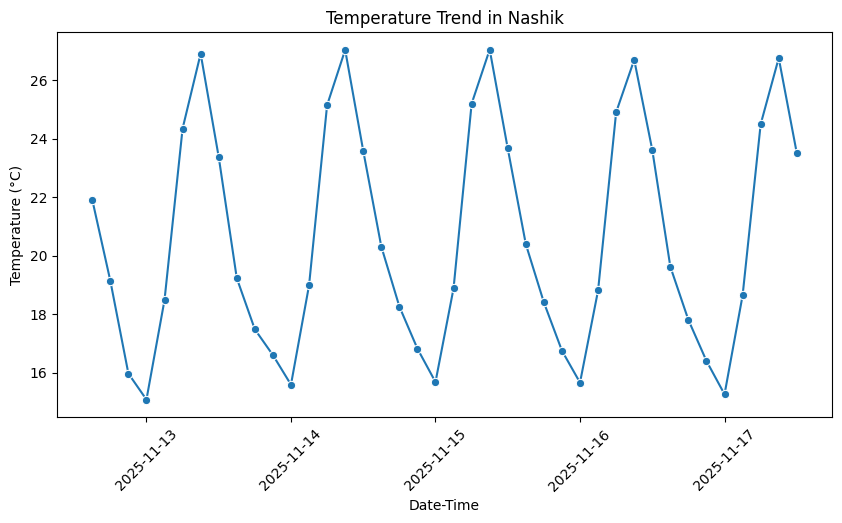

In [32]:
# Plot Temperature Trend
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='Date_Time', y='Temperature_C', marker='o')
plt.title(f"Temperature Trend in {city_name}")
plt.xlabel("Date-Time")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45)
plt.show()

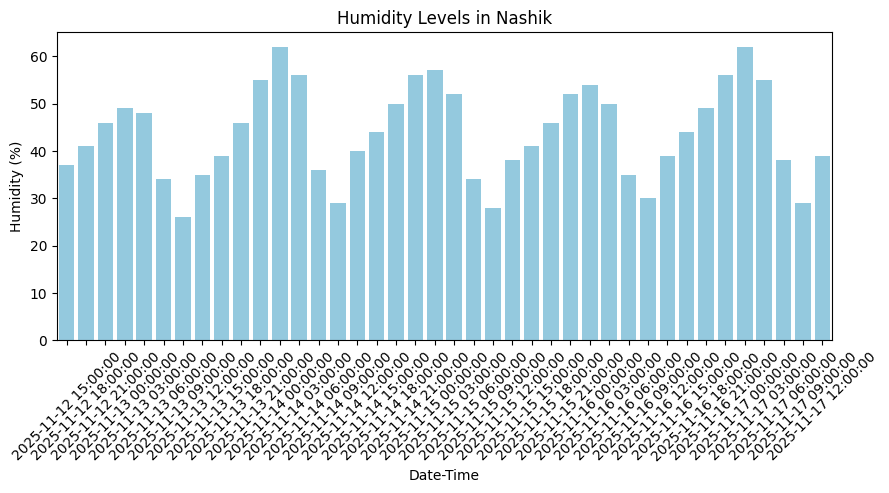

In [33]:
# Plot Humidity Levels
plt.figure(figsize=(10, 4))
sns.barplot(data=df, x='Date_Time', y='Humidity_%', color='skyblue')
plt.title(f"Humidity Levels in {city_name}")
plt.xlabel("Date-Time")
plt.ylabel("Humidity (%)")
plt.xticks(rotation=45)
plt.show()

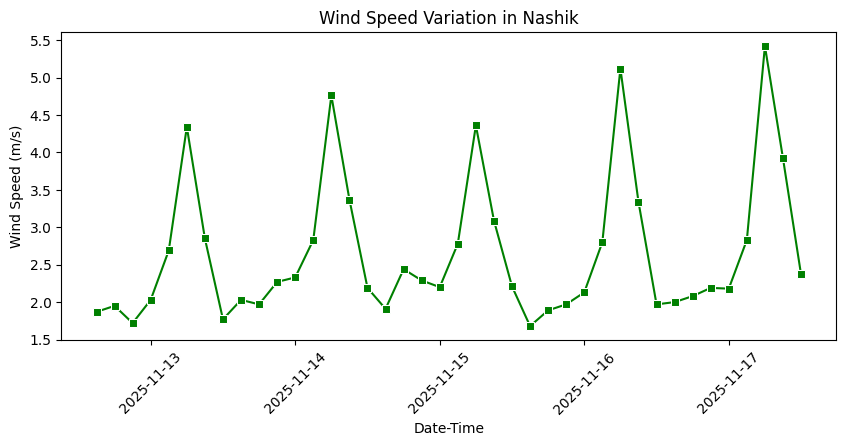

In [34]:
# Plot Wind Speed
plt.figure(figsize=(10, 4))
sns.lineplot(data=df, x='Date_Time', y='Wind_Speed_mps', marker='s', color='green')
plt.title(f"Wind Speed Variation in {city_name}")
plt.xlabel("Date-Time")
plt.ylabel("Wind Speed (m/s)")
plt.xticks(rotation=45)
plt.show()

In [36]:
df['Date'] = df['Date_Time'].dt.date

daily_stats = df.groupby('Date').agg(
    Avg_Temp=('Temperature_C', 'mean'),
    Max_Temp=('Temperature_C', 'max'),
    Min_Temp=('Temperature_C', 'min'),
    Avg_Humidity=('Humidity_%', 'mean'),
    Total_Rain=('Rain_mm', 'sum'),
    Avg_Wind=('Wind_Speed_mps', 'mean')
).reset_index()

# Note: The PDF code had a two-step process. This modern 'agg' is cleaner.
print("\nDaily Aggregated Statistics:")
print(daily_stats)


Daily Aggregated Statistics:
         Date   Avg_Temp  Max_Temp  Min_Temp  Avg_Humidity Total_Rain  \
0  2025-11-12  19.006667     21.91     15.97     41.333333          0   
1  2025-11-13  20.185000     26.90     15.08     41.500000          0   
2  2025-11-14  20.713750     27.03     15.59     46.625000          0   
3  2025-11-15  20.748750     27.04     15.68     43.500000          0   
4  2025-11-16  20.436250     26.69     15.66     44.625000          0   
5  2025-11-17  21.728000     26.75     15.26     44.600000          0   

   Avg_Wind  
0  1.846667  
1  2.493750  
2  2.765000  
3  2.522500  
4  2.703750  
5  3.344000  


In [37]:
# Get coordinates from the original API data
lat = data['city']['coord']['lat']
lon = data['city']['coord']['lon']

map_weather = folium.Map(location=[lat, lon], zoom_start=10)
folium.Marker(location=[lat, lon], popup=f"{city_name} Weather").add_to(map_weather)

# In a Jupyter/Colab notebook, this will display the map
map_weather

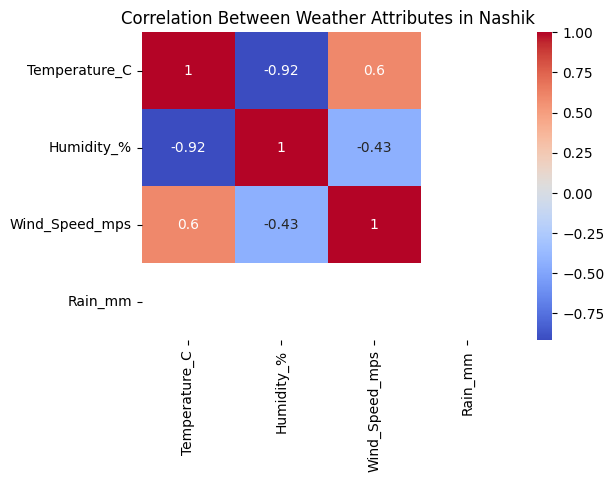

In [38]:
# Select only numerical columns for correlation
corr_df = df[['Temperature_C', 'Humidity_%', 'Wind_Speed_mps', 'Rain_mm']]
corr = corr_df.corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f"Correlation Between Weather Attributes in {city_name}")
plt.show()